In [1]:
pip install numpy pandas matplotlib yfinance arch scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8")


In [3]:
ticker = "^NSEI"   # NIFTY 50 index
start_date = "2014-01-01"
end_date = "2024-12-31"

data = yf.download(ticker, start=start_date, end=end_date)
data.head()


/tmp/ipython-input-3933048146.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2014-01-02,6221.149902,6358.299805,6211.299805,6301.250000,158100
2014-01-03,6211.149902,6221.700195,6171.250000,6194.549805,139000
2014-01-06,6191.450195,6224.700195,6170.250000,6220.850098,118300
2014-01-07,6162.250000,6221.500000,6144.750000,6203.899902,138600
2014-01-08,6174.600098,6192.100098,6160.350098,6178.049805,146900


In [4]:
prices = data["Close"].dropna()
prices.name = "Price"


In [5]:
returns = np.log(prices / prices.shift(1)).dropna()
returns.name = "Log Returns"


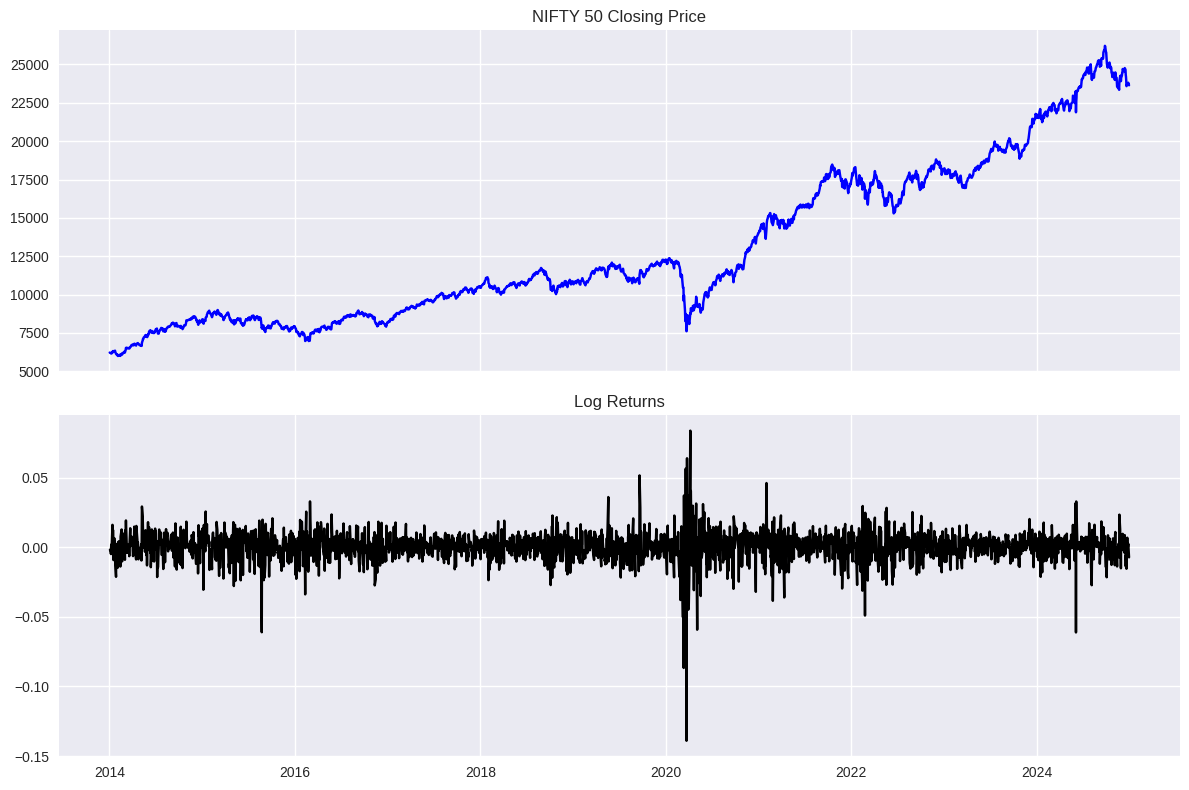

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(prices, color="blue")
ax[0].set_title("NIFTY 50 Closing Price")

ax[1].plot(returns, color="black")
ax[1].set_title("Log Returns")

plt.tight_layout()
plt.show()


In [7]:
rolling_vol_20 = returns.rolling(window=20).std()
rolling_vol_60 = returns.rolling(window=60).std()


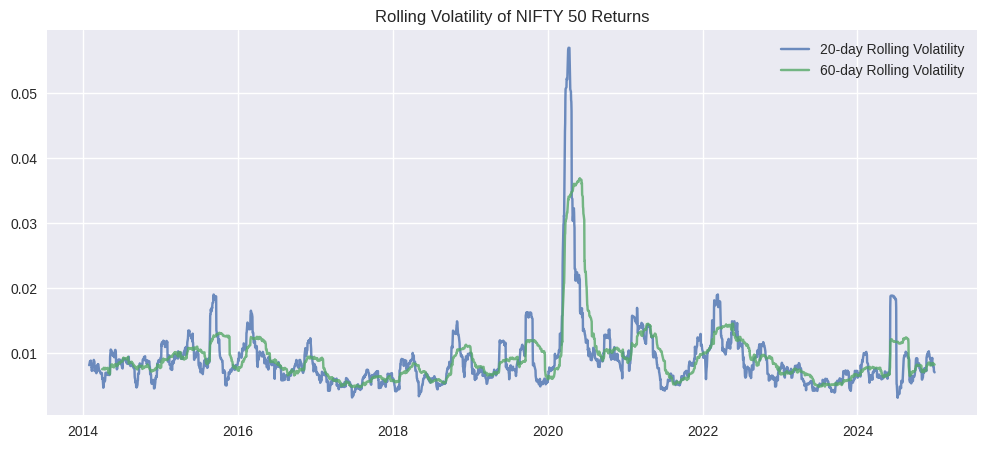

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(rolling_vol_20, label="20-day Rolling Volatility", alpha=0.8)
plt.plot(rolling_vol_60, label="60-day Rolling Volatility", alpha=0.8)
plt.legend()
plt.title("Rolling Volatility of NIFTY 50 Returns")
plt.show()


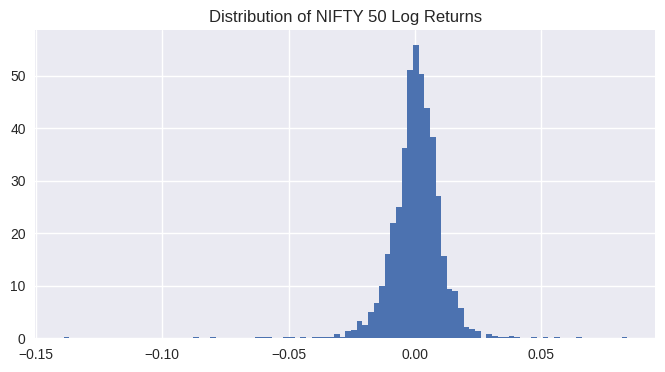

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(returns, bins=100, density=True)
plt.title("Distribution of NIFTY 50 Log Returns")
plt.show()


In [10]:
from arch import arch_model


In [11]:
returns_pct = returns * 100


In [12]:
garch_model = arch_model(
    returns_pct,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_result = garch_model.fit(update_freq=10)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 3488.0965778946265
            Iterations: 8
            Function evaluations: 53
            Gradient evaluations: 8


In [13]:
print(garch_result.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^NSEI   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3488.10
Distribution:                  Normal   AIC:                           6984.19
Method:            Maximum Likelihood   BIC:                           7007.79
                                        No. Observations:                 2697
Date:                Sat, Feb 07 2026   Df Residuals:                     2696
Time:                        16:36:41   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0779  1.688e-02      4.612  3.983e-06 [4.478e-0

In [14]:
garch_vol = garch_result.conditional_volatility
garch_vol.name = "GARCH Volatility"


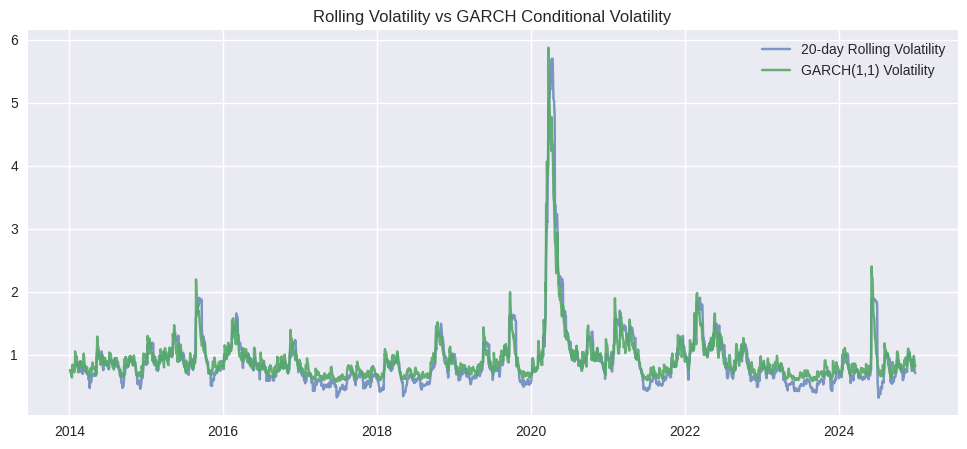

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(rolling_vol_20 * 100, label="20-day Rolling Volatility", alpha=0.7)
plt.plot(garch_vol, label="GARCH(1,1) Volatility", alpha=0.9)
plt.legend()
plt.title("Rolling Volatility vs GARCH Conditional Volatility")
plt.show()


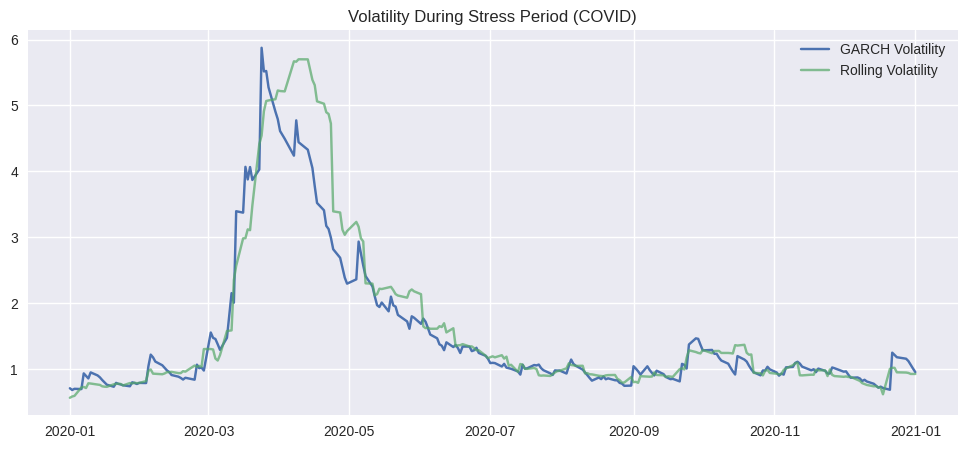

In [16]:
stress_period = (returns_pct.index >= "2020-01-01") & (returns_pct.index <= "2021-01-01")

plt.figure(figsize=(12, 5))
plt.plot(garch_vol[stress_period], label="GARCH Volatility")
plt.plot(rolling_vol_20[stress_period] * 100, label="Rolling Volatility", alpha=0.7)
plt.legend()
plt.title("Volatility During Stress Period (COVID)")
plt.show()



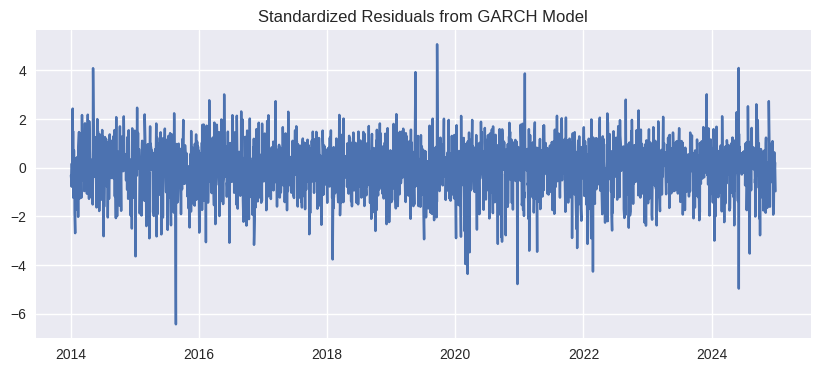

In [17]:
std_resid = garch_result.resid / garch_vol

plt.figure(figsize=(10, 4))
plt.plot(std_resid)
plt.title("Standardized Residuals from GARCH Model")
plt.show()


In [18]:
returns_1d = pd.Series(
    returns_pct.values.flatten(),
    index=returns_pct.index,
    name="Returns"
)


In [19]:
garch_vol_1d = pd.Series(
    garch_vol.values.flatten(),
    index=returns_pct.index,
    name="GARCH_Vol"
)


In [20]:
garch_vol_1d = pd.Series(
    np.asarray(garch_vol).flatten(),
    index=returns_1d.index,
    name="GARCH_Vol"
)


In [21]:
vol_df = pd.concat([returns_1d, garch_vol_1d], axis=1).dropna()


In [22]:
vol_df.shape
vol_df.head()


,Returns,GARCH_Vol
Date,,
2014-01-03,-0.160871,0.755144
2014-01-06,-0.317671,0.727795
2014-01-07,-0.472737,0.710702
2014-01-08,0.200215,0.706571
2014-01-09,-0.101272,0.681176


In [23]:
vol_df.info()
vol_df.head()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2697 entries, 2014-01-03 to 2024-12-30
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Returns    2697 non-null   float64
 1   GARCH_Vol  2697 non-null   float64
dtypes: float64(2)
memory usage: 63.2 KB


,Returns,GARCH_Vol
Date,,
2014-01-03,-0.160871,0.755144
2014-01-06,-0.317671,0.727795
2014-01-07,-0.472737,0.710702
2014-01-08,0.200215,0.706571
2014-01-09,-0.101272,0.681176


In [24]:
low_q = vol_df["GARCH_Vol"].quantile(0.33)
high_q = vol_df["GARCH_Vol"].quantile(0.66)

def classify_regime(vol):
    if vol <= low_q:
        return "Low Volatility"
    elif vol <= high_q:
        return "Medium Volatility"
    else:
        return "High Volatility"

vol_df["Regime"] = vol_df["GARCH_Vol"].apply(classify_regime)


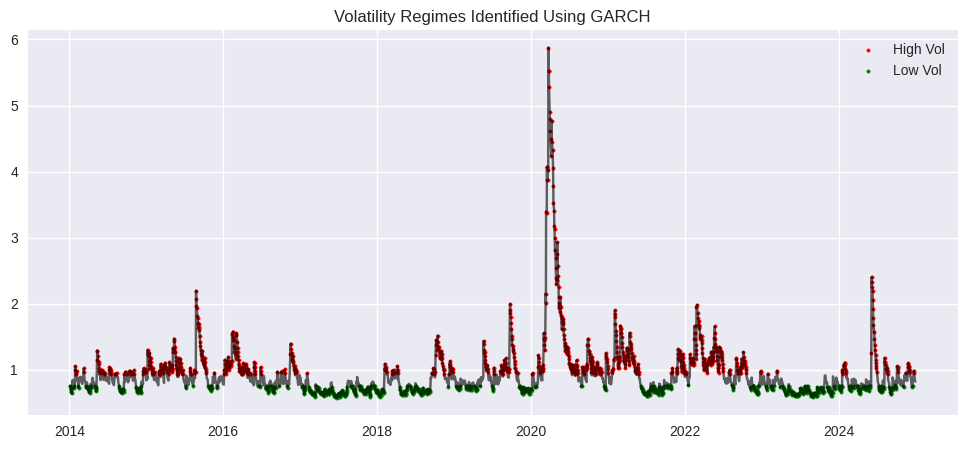

In [25]:
plt.figure(figsize=(12,5))
plt.plot(vol_df["GARCH_Vol"], color="black", alpha=0.6)

plt.scatter(
    vol_df[vol_df["Regime"]=="High Volatility"].index,
    vol_df[vol_df["Regime"]=="High Volatility"]["GARCH_Vol"],
    color="red", s=6, label="High Vol"
)

plt.scatter(
    vol_df[vol_df["Regime"]=="Low Volatility"].index,
    vol_df[vol_df["Regime"]=="Low Volatility"]["GARCH_Vol"],
    color="green", s=6, label="Low Vol"
)

plt.legend()
plt.title("Volatility Regimes Identified Using GARCH")
plt.show()


In [26]:
regime_stats = vol_df.groupby("Regime").agg(
    Avg_Return=("Returns", "mean"),
    Return_Std=("Returns", "std"),
    Avg_Vol=("GARCH_Vol", "mean"),
    Max_Vol=("GARCH_Vol", "max")
)

regime_stats


,Avg_Return,Return_Std,Avg_Vol,Max_Vol
Regime,,,,
High Volatility,0.084288,1.416211,1.265436,5.874532
Low Volatility,0.051350,0.665340,0.683902,0.759754
Medium Volatility,0.011827,0.858313,0.835441,0.928664


In [27]:
vol_df["Regime_Change"] = vol_df["Regime"] != vol_df["Regime"].shift(1)
regime_lengths = vol_df.groupby(vol_df["Regime_Change"].cumsum()).size()

regime_lengths.describe()


,0
count,384.000000
mean,7.023438
std,12.096305
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,115.000000


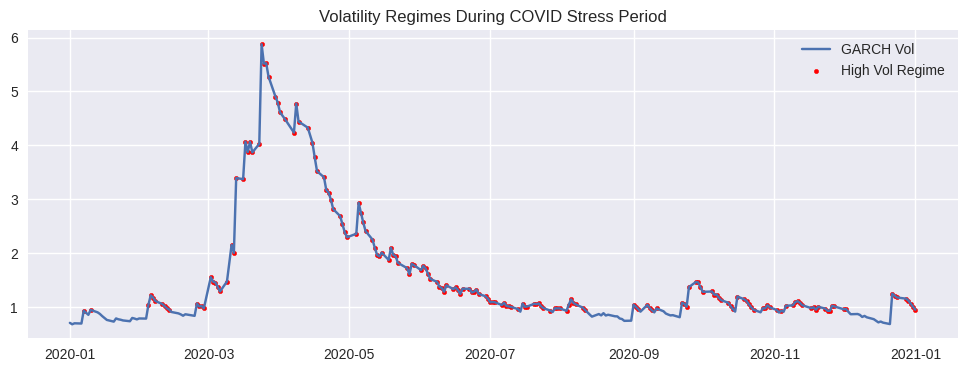

In [28]:
stress = vol_df.loc["2020-01-01":"2021-01-01"]

plt.figure(figsize=(12,4))
plt.plot(stress["GARCH_Vol"], label="GARCH Vol")
plt.scatter(
    stress[stress["Regime"]=="High Volatility"].index,
    stress[stress["Regime"]=="High Volatility"]["GARCH_Vol"],
    color="red", s=10, label="High Vol Regime"
)
plt.legend()
plt.title("Volatility Regimes During COVID Stress Period")
plt.show()


In [29]:
vol_df["Target_Vol"] = vol_df["Returns"]**2


In [30]:
for lag in [1, 5, 10]:
    vol_df[f"ret_lag_{lag}"] = vol_df["Returns"].shift(lag)
    vol_df[f"vol_lag_{lag}"] = vol_df["Target_Vol"].shift(lag)


In [31]:
ml_df = vol_df.dropna().copy()


In [32]:
split_date = "2019-01-01"

train = ml_df.loc[:split_date]
test  = ml_df.loc[split_date:]

X_train = train.filter(like="lag")
y_train = train["Target_Vol"]

X_test  = test.filter(like="lag")
y_test  = test["Target_Vol"]


In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)

In [34]:
test["ML_Vol"] = rf.predict(X_test)


/tmp/ipython-input-2858244613.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["ML_Vol"] = rf.predict(X_test)


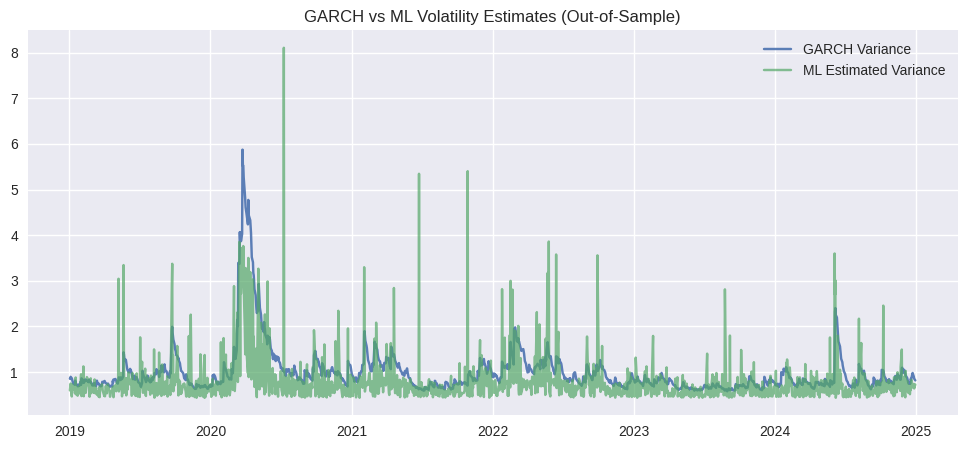

In [35]:
plt.figure(figsize=(12,5))
plt.plot(test["GARCH_Vol"], label="GARCH Variance", alpha=0.9)
plt.plot(test["ML_Vol"], label="ML Estimated Variance", alpha=0.7)
plt.legend()
plt.title("GARCH vs ML Volatility Estimates (Out-of-Sample)")
plt.show()


In [36]:
comparison = test.groupby(vol_df.loc[test.index, "Regime"]).agg(
    Avg_GARCH_Vol=("GARCH_Vol", "mean"),
    Avg_ML_Vol=("ML_Vol", "mean")
)

comparison


,Avg_GARCH_Vol,Avg_ML_Vol
Regime,,
High Volatility,1.363542,0.975253
Low Volatility,0.689614,0.654924
Medium Volatility,0.831151,0.682056


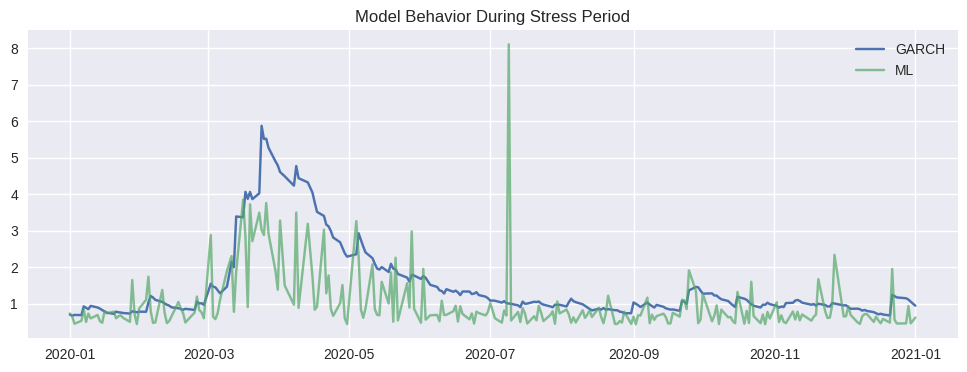

In [37]:
stress_test = test.loc["2020-01-01":"2021-01-01"]

plt.figure(figsize=(12,4))
plt.plot(stress_test["GARCH_Vol"], label="GARCH")
plt.plot(stress_test["ML_Vol"], label="ML", alpha=0.7)
plt.legend()
plt.title("Model Behavior During Stress Period")
plt.show()


In [38]:
test["Realized_Vol"] = test["Target_Vol"]  # squared returns


/tmp/ipython-input-4030596310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Realized_Vol"] = test["Target_Vol"]  # squared returns


In [39]:
from sklearn.metrics import mean_squared_error

mse_garch = mean_squared_error(
    test["Realized_Vol"],
    test["GARCH_Vol"]
)

mse_ml = mean_squared_error(
    test["Realized_Vol"],
    test["ML_Vol"]
)

mse_garch, mse_ml


(41.077671163330365, 42.21175096554092)

In [40]:
regime_perf = test.groupby(vol_df.loc[test.index, "Regime"]).apply(
    lambda df: pd.Series({
        "MSE_GARCH": mean_squared_error(df["Realized_Vol"], df["GARCH_Vol"]),
        "MSE_ML": mean_squared_error(df["Realized_Vol"], df["ML_Vol"])
    })
)

regime_perf


,MSE_GARCH,MSE_ML
Regime,,
High Volatility,105.359230,108.292222
Low Volatility,0.731584,0.785829
Medium Volatility,1.788237,1.772469


In [41]:
noise_garch = test["GARCH_Vol"].std()
noise_ml = test["ML_Vol"].std()

noise_garch, noise_ml


(0.5385116355307659, 0.5339652371105472)

In [42]:
summary = pd.DataFrame({
    "Model": ["GARCH", "ML"],
    "Overall_MSE": [mse_garch, mse_ml],
    "Estimate_Std (Noise)": [noise_garch, noise_ml]
})

summary


,Model,Overall_MSE,Estimate_Std (Noise)
0,GARCH,41.077671,0.538512
1,ML,42.211751,0.533965
